In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Import MCBO's native tools
from mcbo.utils.experiment_utils import get_opt_results
from mcbo.utils.general_plot_utils import plot_curves_with_ranked_legends

# Define your paths and parameters
REPO_ROOT = "/home/felix_jaspersen/Repositories/HEBO/MCBO" 
RESULTS_DIR = os.path.join(REPO_ROOT, "results")


In [2]:
# 1. Force Jupyter to render plots (Overrides the MCBO 'Agg' setting)
%matplotlib inline

# Casmopolitan

In [3]:
# Experiment details
n_init = 20
method_name = "Casmopolitan (gp_to)"

## Ackley53D

In [4]:
# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="ackley-53", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)
results_df.head()

,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time
0,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,1,2.744155,"tensor(2.7442, dtype=torch.float64)",0.044602
1,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,2,2.662415,"tensor(2.6624, dtype=torch.float64)",0.084215
2,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,3,2.906920,"tensor(2.6624, dtype=torch.float64)",0.123895
3,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,4,2.841668,"tensor(2.6624, dtype=torch.float64)",0.162809
4,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,5,2.749591,"tensor(2.6624, dtype=torch.float64)",0.201502


In [5]:
# Quick cleaner for PyTorch tensor strings
if results_df['f(x*)'].dtype == object:
    results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


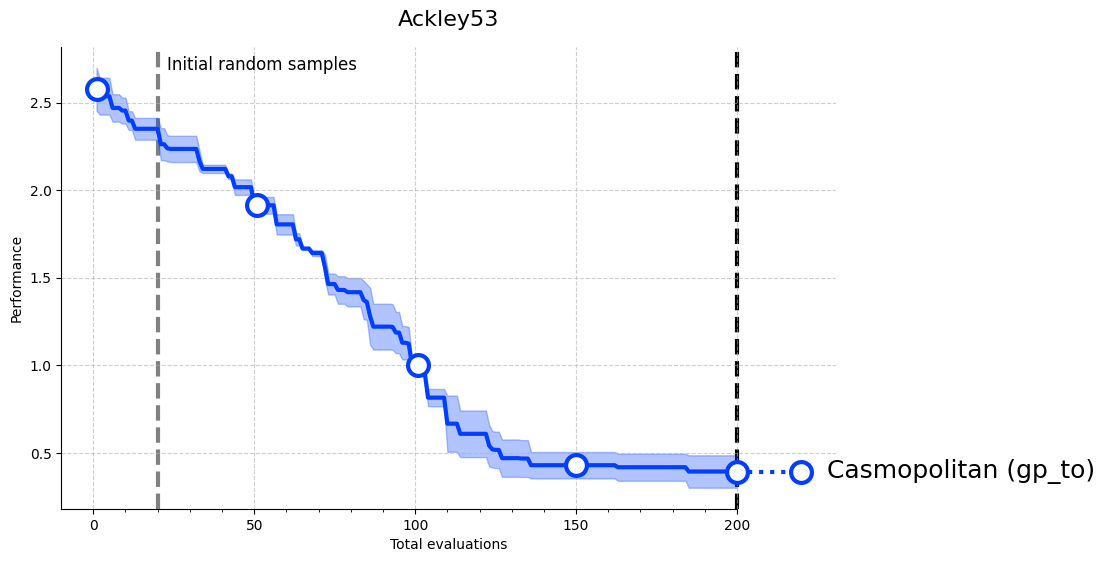

In [6]:
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)

# Vertial line to indicate initialization with random samples
ymin, ymax = ax.get_ylim()
ax.plot([n_init, n_init], [ymin, ymax], linestyle="--", color="grey", linewidth=3, zorder=0)
ax.text(n_init + 3, ymax - (ymax - ymin) * 0.05, "Initial random samples", fontsize=12)

plt.title("Ackley53", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## SVM

In [7]:
# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="svm_opt", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)
results_df.head()

,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time
0,SVM Opt,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,1,242.708354,"tensor(242.7084, dtype=torch.float64)",0.046071
1,SVM Opt,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,2,253.244676,"tensor(242.7084, dtype=torch.float64)",0.083962
2,SVM Opt,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,3,253.870341,"tensor(242.7084, dtype=torch.float64)",0.121581
3,SVM Opt,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,4,245.418300,"tensor(242.7084, dtype=torch.float64)",0.156885
4,SVM Opt,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,5,244.658295,"tensor(242.7084, dtype=torch.float64)",0.192100


In [8]:
# Quick cleaner for PyTorch tensor strings
if results_df['f(x*)'].dtype == object:
    results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


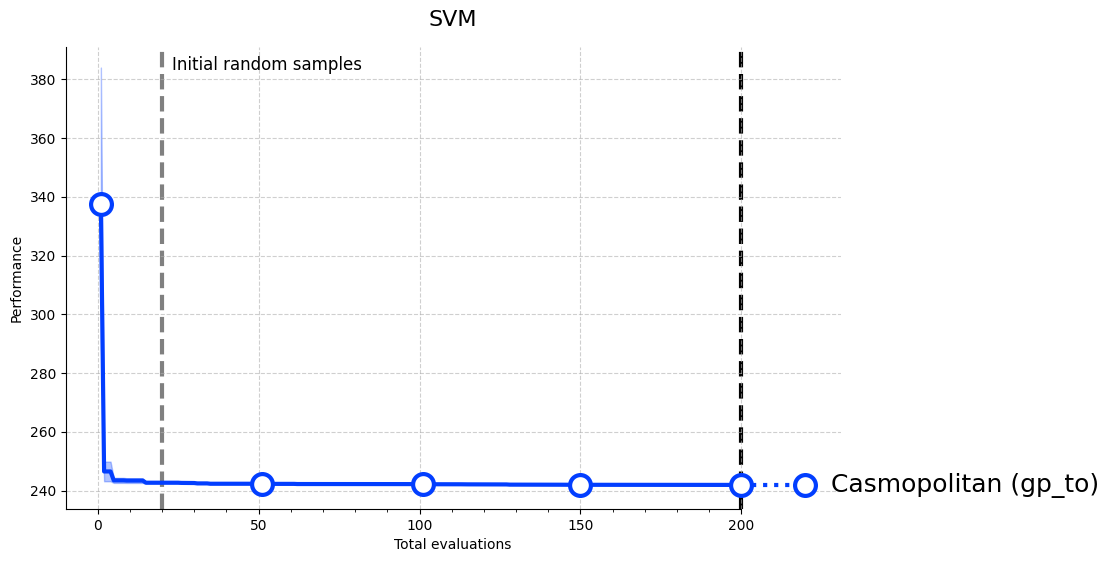

In [9]:
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)

# Vertial line to indicate initialization with random samples
ymin, ymax = ax.get_ylim()
ax.plot([n_init, n_init], [ymin, ymax], linestyle="--", color="grey", linewidth=3, zorder=0)
ax.text(n_init + 3, ymax - (ymax - ymin) * 0.05, "Initial random samples", fontsize=12)

plt.title("SVM", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## XGBoost

In [10]:
# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="xgboost_opt", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)
results_df.head()

,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time
0,XGBoost Opt - mnist,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,1,0.148148,"tensor(0.1481, dtype=torch.float64)",0.035490
1,XGBoost Opt - mnist,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,2,0.083333,"tensor(0.0833, dtype=torch.float64)",0.061234
2,XGBoost Opt - mnist,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,3,0.214815,"tensor(0.0833, dtype=torch.float64)",0.075574
3,XGBoost Opt - mnist,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,4,0.107407,"tensor(0.0833, dtype=torch.float64)",0.087855
4,XGBoost Opt - mnist,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,5,0.083333,"tensor(0.0833, dtype=torch.float64)",0.101161


In [11]:
# Quick cleaner for PyTorch tensor strings
if results_df['f(x*)'].dtype == object:
    results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


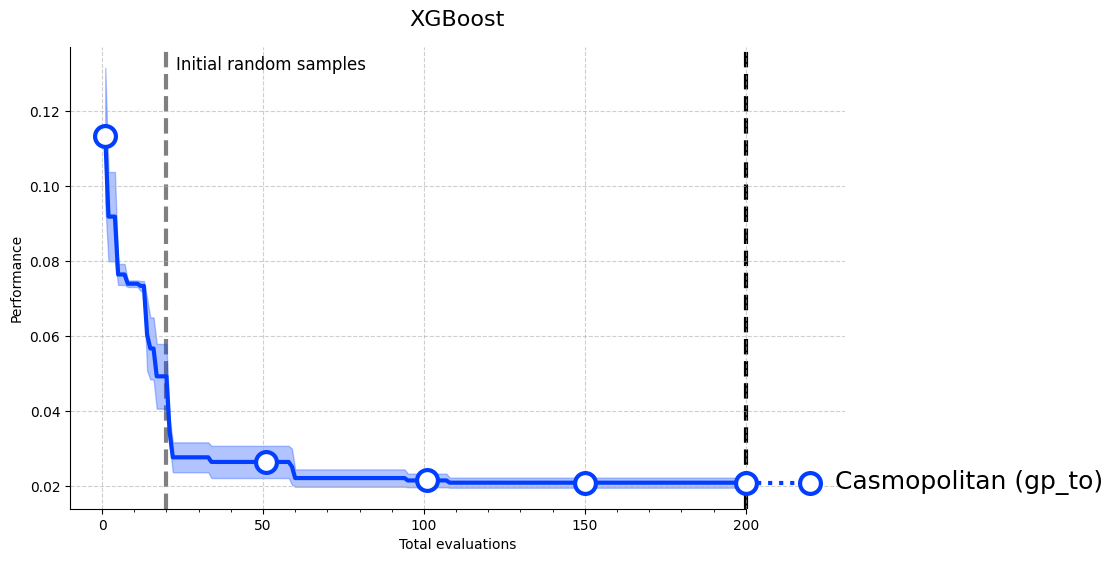

In [12]:
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)

# Vertial line to indicate initialization with random samples
ymin, ymax = ax.get_ylim()
ax.plot([n_init, n_init], [ymin, ymax], linestyle="--", color="grey", linewidth=3, zorder=0)
ax.text(n_init + 3, ymax - (ymax - ymin) * 0.05, "Initial random samples", fontsize=12)

plt.title("XGBoost", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## CoCaBo Func2C

In [18]:
# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="Func2C", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)
results_df.head()

,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time
0,Func2C,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,1,7.402173,"tensor(7.4022, dtype=torch.float64)",0.100055
1,Func2C,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,2,0.481015,"tensor(0.4810, dtype=torch.float64)",0.135568
2,Func2C,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,3,0.342876,"tensor(0.3429, dtype=torch.float64)",0.148649
3,Func2C,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,4,1.443435,"tensor(0.3429, dtype=torch.float64)",0.159080
4,Func2C,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,5,1.352079,"tensor(0.3429, dtype=torch.float64)",0.169223


In [19]:
# Quick cleaner for PyTorch tensor strings
if results_df['f(x*)'].dtype == object:
    results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


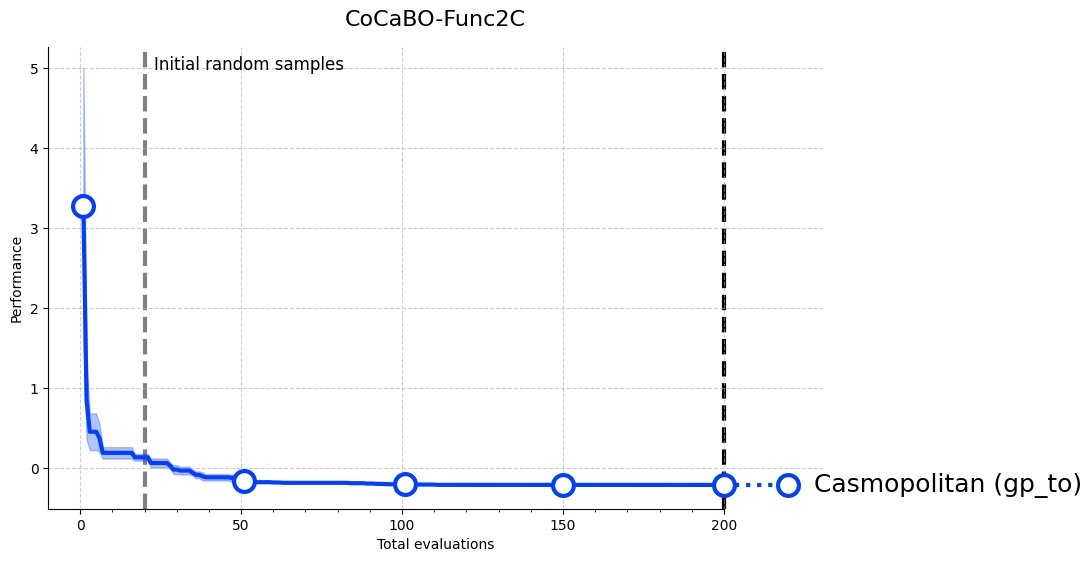

In [20]:
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)

# Vertial line to indicate initialization with random samples
ymin, ymax = ax.get_ylim()
ax.plot([n_init, n_init], [ymin, ymax], linestyle="--", color="grey", linewidth=3, zorder=0)
ax.text(n_init + 3, ymax - (ymax - ymin) * 0.05, "Initial random samples", fontsize=12)

plt.title("CoCaBO-Func2C", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## CoCaBO Func3C

In [21]:
# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="Func3C", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)
results_df.head()

Func3C gp_to__is__ei__basic 42
Func3C gp_to__is__ei__basic 43
Func3C gp_to__is__ei__basic 44


,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time


In [22]:
# Quick cleaner for PyTorch tensor strings
if results_df['f(x*)'].dtype == object:
    results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


ValueError: min() arg is an empty sequence

In [ ]:
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)

# Vertial line to indicate initialization with random samples
ymin, ymax = ax.get_ylim()
ax.plot([n_init, n_init], [ymin, ymax], linestyle="--", color="grey", linewidth=3, zorder=0)
ax.text(n_init + 3, ymax - (ymax - ymin) * 0.05, "Initial random samples", fontsize=12)

plt.title("CoCaBO-Func3C", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Omitted code

In [ ]:
# Dictionaries for Plot 2 (BO Iterations Only)
data_y_bo = {method_name: data_y_total[method_name][:, n_init:]}
data_x_bo = {method_name: data_x_total[method_name][n_init:] - n_init}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_bo,
    data_x=data_x_bo,
    show_std_error=True,
    min_is_the_best=True
)
plt.title("Performance vs. BO Iterations", fontsize=16, pad=15)
plt.xlabel("Number of BO Iterations (Post-Initialization)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()